In [37]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from tensorflow.data import Dataset

In [ ]:
DATASET_PATH = "./Dataset"
images = []

for filename in os.listdir(DATASET_PATH):
    img = load_img(f"{DATASET_PATH}/{filename}", target_size=(64, 64))
    img = img_to_array(img)
    images.append(img)

In [39]:
images = np.asarray(images).astype(np.float32) / 255.0

total = len(images)
split = int(total * 0.8)

x_train = images[:split]
x_test = images[split:]

IMAGE_ORIGINAL_SHAPE = x_train.shape[1:]
IMAGE_SIZE = IMAGE_ORIGINAL_SHAPE[0] * IMAGE_ORIGINAL_SHAPE[1] * IMAGE_ORIGINAL_SHAPE[2]

BATCH_SIZE = 8
MAX_EPOCHS = 20
LATENT_DIM = 32
HIDDEN_DIM_1 = 512
HIDDEN_DIM_2 = 256
LEARNING_RATE = 0.0001

In [40]:
dataset = Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(BATCH_SIZE * 5).batch(BATCH_SIZE)

In [41]:
class VAE(Model):
    def __init__(self, hidden_dim1, hidden_dim2, latent_dim, **kwargs):
        super(VAE, self).__init__(**kwargs)

        self.fc1 = Dense(hidden_dim1, activation='relu')
        self.enc1 = BatchNormalization()
        self.fc2 = Dropout(0.2)

        self.fc3 = Dense(hidden_dim2, activation='relu')
        self.enc2 = BatchNormalization()
        self.fc4 = Dropout(0.2)

        self.fc5 = Dense(latent_dim)
        self.fc6 = Dense(latent_dim)

        self.fc7 = Dense(hidden_dim2)
        self.dec1 = BatchNormalization()
        self.fc8 = Dropout(0.2)

        self.fc9 = Dense(hidden_dim1)
        self.dec2 = BatchNormalization()
        self.fc10 = Dense(IMAGE_SIZE)

        self.dec3 = BatchNormalization()

    def encode(self, x):
        x = self.fc1(x)
        x = self.enc1(x)
        x = self.fc2(x)

        x = self.fc3(x)
        x = self.enc2(x)
        x = self.fc4(x)

        mu = self.fc5(x)
        log_var = self.fc6(x)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        std = tf.exp(log_var * 0.5)
        eps = tf.random.normal(std.shape)
        return mu + std * eps
    
    def decode_logits(self, z):
        z = self.fc7(z)
        z = self.dec1(z)
        z = self.fc8(z)

        z = self.fc9(z)
        z = self.dec2(z)
        z = self.fc10(z)

        z = self.dec3(z)
        return z
    
    def decode(self, z):
        return tf.nn.sigmoid(self.decode_logits(z))
    
    def call(self, inputs):
        mu, log_var = self.encode(inputs)
        z = self.reparameterize(mu, log_var)
        x_recon_logits = self.decode_logits(z)
        return x_recon_logits, mu, log_var

In [ ]:
model = VAE(HIDDEN_DIM_1, HIDDEN_DIM_2, LATENT_DIM)
model(tf.zeros((BATCH_SIZE, IMAGE_SIZE)))
optimizer = Adam(LEARNING_RATE)

model.summary()

In [45]:
loss_history = []
kl_div_history = []

for epoch in range(MAX_EPOCHS):
    for x in dataset:
        x = tf.reshape(x, [-1, IMAGE_SIZE])
        with tf.GradientTape() as tape:
            x_recon_logits, mu, log_var = model(x)
            recon_loss = tf.nn.sigmoid_cross_entropy_with_logits(x, x_recon_logits)
            recon_loss = tf.reduce_mean(tf.reduce_sum(recon_loss, axis=1))

            kl_div = -0.5 * tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
            kl_div = tf.reduce_mean(kl_div)
            loss = recon_loss + kl_div

        gradients = tape.gradient(loss, model.trainable_variables)
        gradients = [tf.clip_by_norm(g, 15) for g in gradients]

        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    print(f"Epoch [{epoch + 1}/{MAX_EPOCHS}]: recon_loss: {recon_loss:.2f} | KLDiv: {kl_div:.2f} | loss: {loss:.2f}")

    loss_history.append(recon_loss)
    kl_div_history.append(kl_div)

Epoch [1/20]: recon_loss: 6662.75 | KLDiv: 41.08 | loss: 6703.83
Epoch [2/20]: recon_loss: 6653.04 | KLDiv: 30.13 | loss: 6683.18
Epoch [3/20]: recon_loss: 6447.21 | KLDiv: 37.74 | loss: 6484.94
Epoch [4/20]: recon_loss: 6551.15 | KLDiv: 34.98 | loss: 6586.13
Epoch [5/20]: recon_loss: 6544.22 | KLDiv: 36.72 | loss: 6580.95
Epoch [6/20]: recon_loss: 6558.88 | KLDiv: 33.53 | loss: 6592.41
Epoch [7/20]: recon_loss: 6406.47 | KLDiv: 37.96 | loss: 6444.43
Epoch [8/20]: recon_loss: 6543.42 | KLDiv: 37.39 | loss: 6580.81
Epoch [9/20]: recon_loss: 6489.92 | KLDiv: 33.38 | loss: 6523.30
Epoch [10/20]: recon_loss: 6629.54 | KLDiv: 44.04 | loss: 6673.57
Epoch [11/20]: recon_loss: 6801.66 | KLDiv: 38.92 | loss: 6840.58
Epoch [12/20]: recon_loss: 6461.08 | KLDiv: 39.15 | loss: 6500.23
Epoch [13/20]: recon_loss: 6451.36 | KLDiv: 43.22 | loss: 6494.59
Epoch [14/20]: recon_loss: 6427.25 | KLDiv: 42.23 | loss: 6469.48
Epoch [15/20]: recon_loss: 6617.73 | KLDiv: 42.23 | loss: 6659.96
Epoch [16/20]: reco

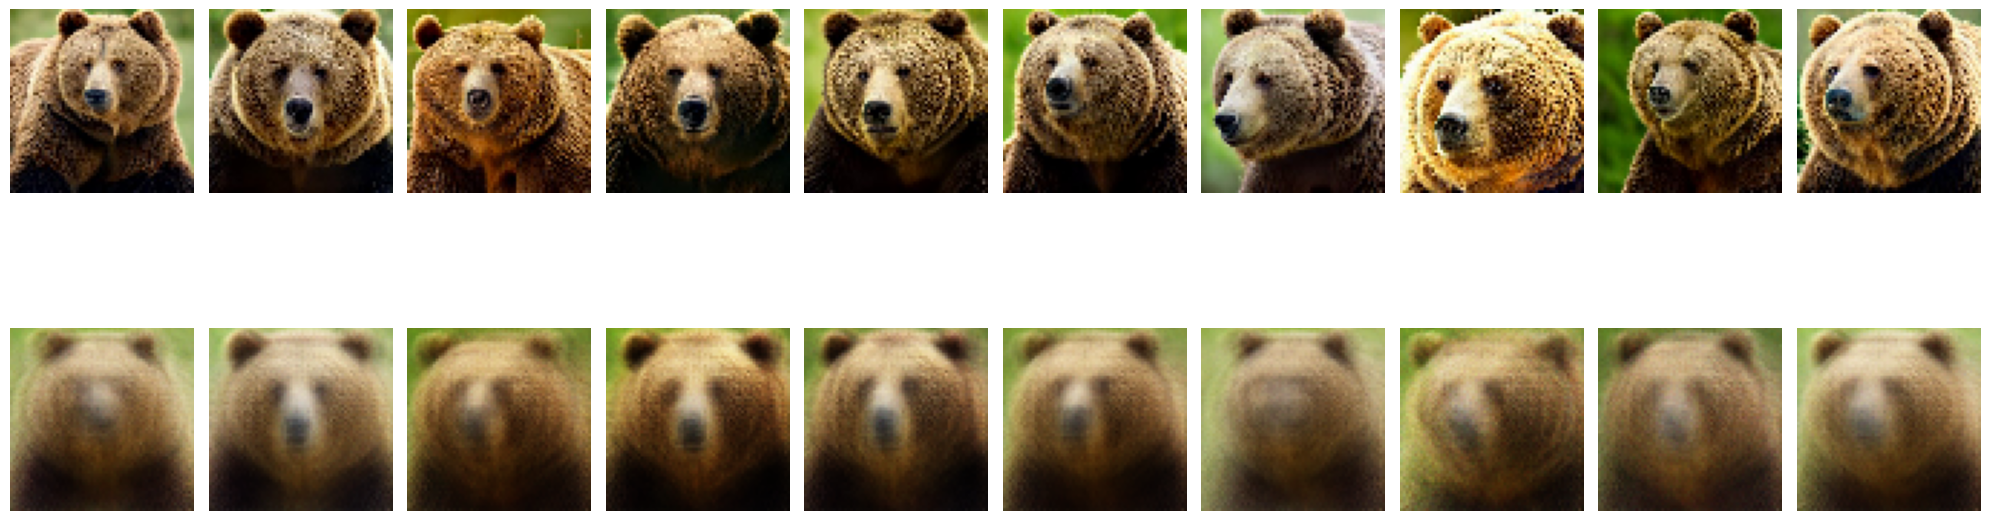

In [52]:
mu, log_var = model.encode(x_test.reshape(-1, IMAGE_SIZE))
z = model.reparameterize(mu, log_var)
out = model.decode(z)
out = tf.reshape(out, [-1, IMAGE_ORIGINAL_SHAPE[0], IMAGE_ORIGINAL_SHAPE[1], IMAGE_ORIGINAL_SHAPE[2]]).numpy() * 255
out = out.astype(np.uint8)

num = 10
plt.figure(figsize=(20, 8))
for i in range(num):
    plt.subplot(2, num, i+1)
    plt.imshow(x_test[i].reshape(IMAGE_ORIGINAL_SHAPE), cmap='gray')
    plt.axis("off")
    plt.subplot(2, num, num+i+1)
    plt.imshow(out[i].reshape(IMAGE_ORIGINAL_SHAPE), cmap='gray')
    plt.axis("off")

plt.tight_layout()
plt.show()

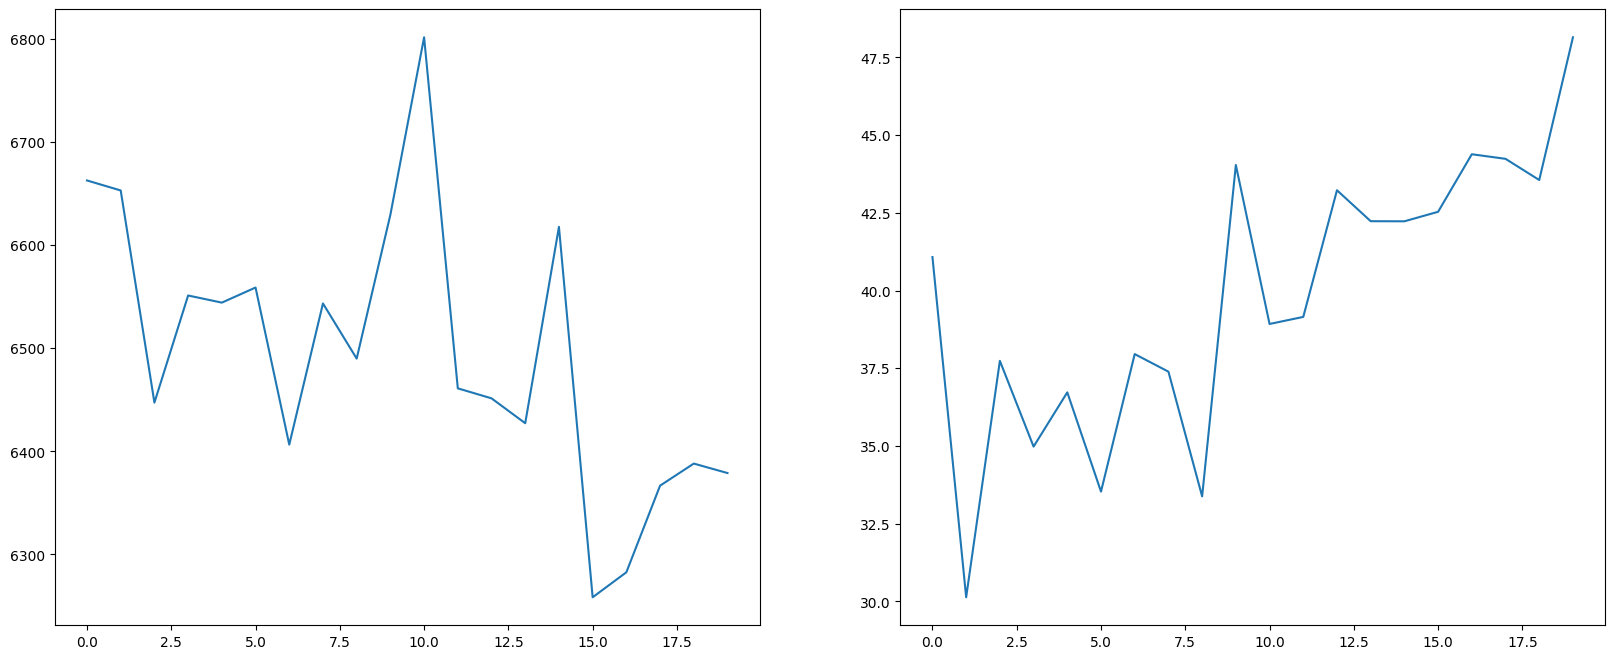

In [53]:
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.subplot(1, 2, 2)
plt.plot(kl_div_history)
plt.show()